<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/NHIS_2025_Sleep_Health_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond Predictive Accuracy: Sleep Health Risk Prediction with NHIS 2025

**Research objective.** Build and compare Python-based machine-learning models for poor sleep health, then evaluate discrimination, calibration, interpretability, and subgroup performance.

**Data source:** CDC/NCHS 2025 National Health Interview Survey (NHIS), Sample Adult public-use file.

> This notebook is a research workflow, not a clinical diagnostic tool. It intentionally discovers and validates sleep variables before constructing the outcome, because NHIS public-use variables can change by year.

## Research questions
1. Which available demographic, socioeconomic, behavioral, and health factors are associated with poor sleep health?
2. How do Logistic Regression, Random Forest, and XGBoost compare on an untouched test set?
3. Which predictors drive model decisions?
4. Does performance differ across sex and age subgroups?

**Primary outcome rule:** Poor self-rated sleep health was defined from WPHSLEEP_A as Fair/Poor versus Excellent/Very Good/Good, with non-substantive responses excluded.

In [2]:
# CELL 1 — Install dependencies
!pip -q install xgboost shap optuna

In [3]:
# CELL 2 — Imports and reproducibility
import io, os, re, json, zipfile, warnings, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
 recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve, brier_score_loss,
 ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

In [4]:
# CELL 3 — Download official CDC 2025 NHIS Sample Adult CSV
URL = 'https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/NHIS/2025/adult25csv.zip'
zip_path='/content/adult25csv.zip'
urllib.request.urlretrieve(URL, zip_path)
with zipfile.ZipFile(zip_path) as z:
    print('ZIP contents:', z.namelist())
    csv_name=[n for n in z.namelist() if n.lower().endswith('.csv')][0]
    z.extract(csv_name, '/content')
df=pd.read_csv('/content/'+csv_name, low_memory=False)
print('Shape:', df.shape)
display(df.head())

ZIP contents: ['adult25.csv', 'readme.txt']
Shape: (24215, 577)


,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,DISAB3_A,SCHDYMSSTC_A,AFNOW,PHQCAT_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,RECTYPE,IMPNUM_A,ADHDAGETC_A,WPHINDEX_A,WTFA_A,HHX,POVRATTC_A
0,6,0,1,2,1,1,1,NaN,NaN,3,...,2,3,1,10,1,NaN,26,10636.862,H012128,1.58
1,12,0,1,3,2,1,2,NaN,NaN,1,...,1,4,1,10,1,NaN,34,2996.860,H000617,4.32
2,1,0,0,2,1,1,2,0.0,2.0,2,...,2,3,1,10,1,5.0,26,29032.445,H033243,0.18
3,14,0,0,3,2,2,2,NaN,NaN,1,...,1,4,1,10,1,NaN,30,7875.107,H049140,6.32
4,13,0,1,3,2,2,2,NaN,2.0,1,...,2,2,1,10,1,NaN,33,4824.620,H012797,4.90


In [5]:
# CELL 4 — Data integrity and sleep-variable discovery
print('Duplicate rows:', df.duplicated().sum())
print('Survey years:', df['SRVY_YR'].dropna().unique() if 'SRVY_YR' in df else 'not found')
sleep_cols=[c for c in df.columns if any(k in c.upper() for k in ['SLP','SLEEP','REST','INSOM'])]
print('Candidate sleep variables:', sleep_cols)
for c in sleep_cols:
    print('\n',c, '| dtype:',df[c].dtype,'| missing:',round(df[c].isna().mean(),3))
    print(df[c].value_counts(dropna=False).head(15))

Duplicate rows: 0
Survey years: [2025]
Candidate sleep variables: ['VSLPALF_A', 'VSLPA_A', 'WPHSLEEP_A']

 VSLPALF_A | dtype: float64 | missing: 0.983
VSLPALF_A
NaN    23811
3.0      164
2.0      121
1.0      101
4.0       15
9.0        3
Name: count, dtype: int64

 VSLPA_A | dtype: float64 | missing: 0.834
VSLPA_A
NaN    20191
2.0     3610
1.0      404
8.0        6
9.0        2
7.0        2
Name: count, dtype: int64

 WPHSLEEP_A | dtype: int64 | missing: 0.0
WPHSLEEP_A
3    8731
2    5374
4    4708
1    3116
5    2271
7       8
9       7
Name: count, dtype: int64


## Outcome construction
WPHSLEEP_A measures self-rated sleep health from Excellent to Poor. The binary outcome classifies Excellent, Very Good, and Good as favorable sleep health and Fair or Poor as poor self-rated sleep health.

In [6]:
# CELL 5 — Construct poor self-rated sleep health target

# NHIS WPHSLEEP_A:
# 1 = Excellent
# 2 = Very Good
# 3 = Good
# 4 = Fair
# 5 = Poor
# 7 = Refused
# 8 = Not Ascertained
# 9 = Don't Know

sleep_labels = {
    1: "Excellent",
    2: "Very Good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

# Human-readable sleep rating for descriptive analysis
df["sleep_rating"] = df["WPHSLEEP_A"].map(sleep_labels)

# Binary prediction target:
# 0 = Excellent / Very Good / Good
# 1 = Fair / Poor
# NaN = non-substantive responses
y = pd.Series(
    np.select(
        [
            df["WPHSLEEP_A"].isin([1, 2, 3]),
            df["WPHSLEEP_A"].isin([4, 5])
        ],
        [0, 1],
        default=np.nan
    ),
    index=df.index,
    name="poor_sleep_health"
)

print("Self-rated sleep distribution:")
print(
    df["sleep_rating"]
    .value_counts()
    .reindex(["Excellent", "Very Good", "Good", "Fair", "Poor"])
)

print("\nBinary outcome counts:")
print(y.value_counts(dropna=False).sort_index())

print("\nBinary outcome proportions:")
print(y.value_counts(normalize=True, dropna=True).sort_index())

print(
    f"\nPoor self-rated sleep prevalence: "
    f"{y.mean():.1%}"
)

Self-rated sleep distribution:
sleep_rating
Excellent    3116
Very Good    5374
Good         8731
Fair         4708
Poor         2271
Name: count, dtype: int64

Binary outcome counts:
poor_sleep_health
0.0    17221
1.0     6979
NaN       15
Name: count, dtype: int64

Binary outcome proportions:
poor_sleep_health
0.0    0.711612
1.0    0.288388
Name: proportion, dtype: float64

Poor self-rated sleep prevalence: 28.8%


Predictor Selection and Leakage Control

In [7]:
# CELL 6 — Candidate predictors and leakage controls

# Candidate predictors selected for interpretability and relevance.
# Only variables actually present in the 2025 NHIS file are retained.

requested = [
    "AGEP_A",
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "PHSTAT_A",
    "LSATIS4_A",
    "REGION",
    "URBRRL23",
    "MARSTAT_A",
    "EMPWRKLSW1_A",
    "BMICAT_A",
    "SMKCIGST_A",
    "DRKSTAT_A",
    "PA18_02R_A",
    "HYPENEV_A",
    "CHLEV_A",
    "DIBEV_A",
    "ANXEV_A",
    "DEPEV_A",
    "PHQCAT_A",
    "GADCAT_A"
]

# Retain variables available in the dataset
features = [c for c in requested if c in df.columns]

# Prevent target leakage:
# exclude all identified sleep-related variables from predictors
features = [c for c in features if c not in sleep_cols]

print(f"Predictors retained ({len(features)}):")
print(features)

if len(features) < 5:
    raise ValueError(
        "Too few candidate predictors were found. "
        "Review the 2025 NHIS variable names before modeling."
    )

# Build analytic dataset
model_df = df[features].copy()
model_df["target"] = y

# Remove observations without a valid sleep-health outcome
model_df = model_df.dropna(subset=["target"]).copy()
model_df["target"] = model_df["target"].astype(int)

print(f"\nAnalytic N: {len(model_df):,}")
print(
    f"Poor self-rated sleep prevalence: "
    f"{model_df['target'].mean():.1%}"
)

Predictors retained (19):
['AGEP_A', 'SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'PHSTAT_A', 'LSATIS4_A', 'REGION', 'URBRRL23', 'MARSTAT_A', 'EMPWRKLSW1_A', 'BMICAT_A', 'SMKCIGST_A', 'CHLEV_A', 'DIBEV_A', 'ANXEV_A', 'DEPEV_A', 'PHQCAT_A', 'GADCAT_A']

Analytic N: 24,200
Poor self-rated sleep prevalence: 28.8%


Clean Special-Response Codes

In [8]:
# CELL 7 — NHIS special-code handling and data-quality validation

X = model_df[features].copy()
y = model_df["target"].copy()

# -------------------------------------------------------------------
# NHIS special-response codes
# -------------------------------------------------------------------
# NHIS commonly uses terminal codes for responses such as:
#   Refused
#   Not ascertained
#   Don't know
#
# IMPORTANT:
# Codes are variable-specific. A value such as 7, 8, or 9 must NOT
# automatically be considered missing because it can be a valid
# substantive category for another NHIS variable.
#
# The mappings below are deliberately defined by variable rather
# than globally.
# -------------------------------------------------------------------

special_codes = {

    # Demographic variables
    "SEX_A":        [7, 8, 9],
    "HISPALLP_A":   [7, 8, 9],
    "RACEALLP_A":   [97, 98, 99],
    "EDUCP_A":      [97, 98, 99],
    "MARSTAT_A":    [7, 8, 9],

    # General health / well-being
    "PHSTAT_A":     [7, 8, 9],
    "LSATIS4_A":    [7, 8, 9],

    # Employment
    "EMPWRKLSW1_A": [7, 8, 9],

    # Health behaviors / status
    "BMICAT_A":     [7, 8, 9],
    "SMKCIGST_A":   [7, 8, 9],
    "DRKSTAT_A":    [7, 8, 9],

    # Chronic conditions
    "HYPENEV_A":    [7, 8, 9],
    "CHLEV_A":      [7, 8, 9],
    "DIBEV_A":      [7, 8, 9],

    # Mental health
    "ANXEV_A":      [7, 8, 9],
    "DEPEV_A":      [7, 8, 9],
    "PHQCAT_A":     [7, 8, 9],
    "GADCAT_A":     [7, 8, 9],

    # Physical activity
    "PA18_02R_A":   [7, 8, 9],
}


# -------------------------------------------------------------------
# Variables intentionally NOT globally recoded
# -------------------------------------------------------------------
#
# AGEP_A:
# Age is treated as a continuous/recode variable. Do not interpret
# ordinary values 7, 8, or 9 as missing ages.
#
# REGION:
# Geographic categories should be retained as documented substantive
# categories.
#
# URBRRL23:
# Urban-rural categories should be retained as documented substantive
# categories.
# -------------------------------------------------------------------


# Save a pre-cleaning copy for QA
X_before_codes = X.copy()

# Apply only documented variable-specific mappings
for column, codes in special_codes.items():

    if column in X.columns:

        X[column] = pd.to_numeric(
            X[column],
            errors="coerce"
        )

        X[column] = X[column].replace(
            codes,
            np.nan
        )


# -------------------------------------------------------------------
# QA report: how many values were converted to missing?
# -------------------------------------------------------------------

recode_report = []

for column in X.columns:

    before_missing = X_before_codes[column].isna().sum()
    after_missing = X[column].isna().sum()

    newly_missing = after_missing - before_missing

    recode_report.append({
        "Variable": column,
        "Original missing": before_missing,
        "New special-code missing": newly_missing,
        "Total missing": after_missing,
        "Missing %": 100 * after_missing / len(X)
    })


recode_report = (
    pd.DataFrame(recode_report)
    .sort_values(
        "Missing %",
        ascending=False
    )
    .reset_index(drop=True)
)


print("NHIS special-code recoding report:")
display(recode_report)


# -------------------------------------------------------------------
# Post-cleaning value inspection
# -------------------------------------------------------------------

print("\nRemaining values for categorical predictors:")

for column in X.columns:

    if X[column].nunique(dropna=True) <= 15:

        values = sorted(
            X[column]
            .dropna()
            .unique()
            .tolist()
        )

        print(f"{column}: {values}")


# -------------------------------------------------------------------
# Modeling sample validation
# -------------------------------------------------------------------

print("\nModeling dataset validation")
print("-" * 40)

print(f"Observations: {len(X):,}")
print(f"Predictors: {X.shape[1]}")
print(f"Positive cases: {(y == 1).sum():,}")
print(f"Negative cases: {(y == 0).sum():,}")
print(f"Poor sleep-health prevalence: {y.mean():.1%}")


# Critical safety checks

assert y.isna().sum() == 0, (
    "Outcome contains missing values."
)

assert set(y.unique()) == {0, 1}, (
    "Outcome is not binary."
)

assert 0.10 < y.mean() < 0.50, (
    "Outcome prevalence is outside the expected range. "
    "Recheck WPHSLEEP_A coding."
)

print("\n✓ Outcome validation passed.")

NHIS special-code recoding report:


,Variable,Original missing,New special-code missing,Total missing,Missing %
0,MARSTAT_A,0,7403,7403,30.590909
1,EMPWRKLSW1_A,0,763,763,3.152893
2,SMKCIGST_A,0,673,673,2.780992
3,GADCAT_A,0,612,612,2.528926
4,PHQCAT_A,0,593,593,2.450413
5,BMICAT_A,0,478,478,1.975207
6,HISPALLP_A,0,300,300,1.239669
7,EDUCP_A,0,83,83,0.342975
8,CHLEV_A,0,72,72,0.297521
9,LSATIS4_A,0,61,61,0.252066



Remaining values for categorical predictors:
SEX_A: [1.0, 2.0]
HISPALLP_A: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
RACEALLP_A: [1, 2, 3, 4, 5, 6, 7, 8, 9]
EDUCP_A: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
PHSTAT_A: [1.0, 2.0, 3.0, 4.0, 5.0]
LSATIS4_A: [1.0, 2.0, 3.0, 4.0]
REGION: [1, 2, 3, 4]
URBRRL23: [1, 2, 3, 4]
MARSTAT_A: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
EMPWRKLSW1_A: [1.0, 2.0]
BMICAT_A: [1.0, 2.0, 3.0, 4.0]
SMKCIGST_A: [1.0, 2.0, 3.0, 4.0, 5.0]
CHLEV_A: [1.0, 2.0]
DIBEV_A: [1.0, 2.0]
ANXEV_A: [1.0, 2.0]
DEPEV_A: [1.0, 2.0]
PHQCAT_A: [1.0, 2.0, 3.0, 4.0]
GADCAT_A: [1.0, 2.0, 3.0, 4.0]

Modeling dataset validation
----------------------------------------
Observations: 24,200
Predictors: 19
Positive cases: 6,979
Negative cases: 17,221
Poor sleep-health prevalence: 28.8%

✓ Outcome validation passed.


In [9]:
# CELL 8 — Descriptive characteristics of analytic sample

table1_rows = []

for c in features:
    s = X[c]

    # Treat higher-cardinality numeric variables as continuous
    if pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > 15:
        table1_rows.append({
            "Variable": c,
            "Type": "Continuous",
            "Nonmissing N": s.notna().sum(),
            "Missing %": 100 * s.isna().mean(),
            "Summary": f"{s.mean():.2f} (SD {s.std():.2f})"
        })

    else:
        counts = s.value_counts(dropna=True)

        if len(counts) > 0:
            top_category = counts.index[0]
            top_n = counts.iloc[0]
            top_pct = 100 * top_n / s.notna().sum()

            summary = (
                f"Most common: {top_category} "
                f"({top_n:,}; {top_pct:.1f}%)"
            )
        else:
            summary = "No substantive values"

        table1_rows.append({
            "Variable": c,
            "Type": "Categorical",
            "Nonmissing N": s.notna().sum(),
            "Missing %": 100 * s.isna().mean(),
            "Summary": summary
        })

table1 = pd.DataFrame(table1_rows)

display(table1)

table1.to_csv(
    "/content/table1_characteristics.csv",
    index=False
)

,Variable,Type,Nonmissing N,Missing %,Summary
0,AGEP_A,Continuous,24200,0.000000,54.11 (SD 18.76)
1,SEX_A,Categorical,24175,0.103306,"Most common: 2.0 (12,966; 53.6%)"
2,HISPALLP_A,Categorical,23900,1.239669,"Most common: 2.0 (16,008; 67.0%)"
3,RACEALLP_A,Categorical,24200,0.000000,"Most common: 1 (17,935; 74.1%)"
4,EDUCP_A,Categorical,24117,0.342975,"Most common: 8.0 (5,734; 23.8%)"
5,PHSTAT_A,Categorical,24193,0.028926,"Most common: 2.0 (8,214; 34.0%)"
6,LSATIS4_A,Categorical,24139,0.252066,"Most common: 2.0 (12,036; 49.9%)"
7,REGION,Categorical,24200,0.000000,"Most common: 3 (8,820; 36.4%)"
8,URBRRL23,Categorical,24200,0.000000,"Most common: 3 (7,531; 31.1%)"
9,MARSTAT_A,Categorical,16797,30.590909,"Most common: 1.0 (10,116; 60.2%)"


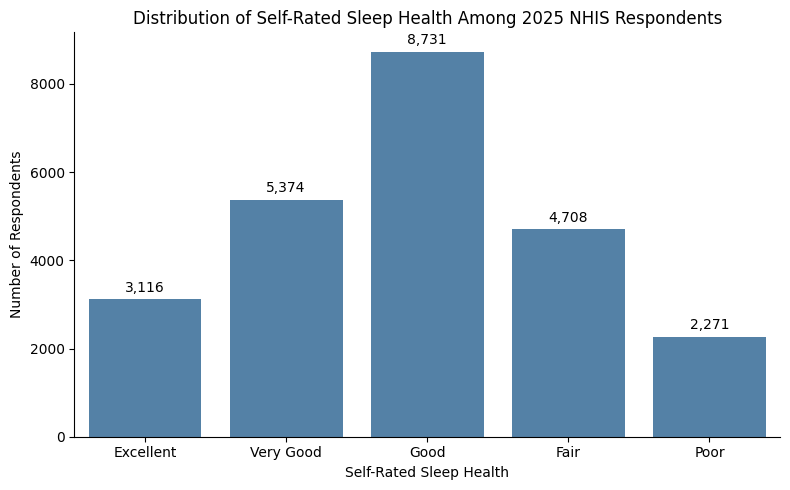

Favorable sleep health: 17,221 (71.2%)
Poor self-rated sleep health: 6,979 (28.8%)


In [10]:
# CELL 9 — Distribution of Self-Rated Sleep Health

sleep_order = [
    "Excellent",
    "Very Good",
    "Good",
    "Fair",
    "Poor"
]

sleep_counts = (
    df["sleep_rating"]
    .value_counts()
    .reindex(sleep_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=sleep_counts.index,
    y=sleep_counts.values,
    color="steelblue",
    ax=ax
)

# Add respondent counts above bars
for i, value in enumerate(sleep_counts.values):
    ax.text(
        i,
        value + 100,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Distribution of Self-Rated Sleep Health Among 2025 NHIS Respondents"
)
ax.set_xlabel("Self-Rated Sleep Health")
ax.set_ylabel("Number of Respondents")

sns.despine()
plt.tight_layout()

plt.savefig(
    "/content/figure1_sleep_health_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Binary outcome summary for model development
print(
    f"Favorable sleep health: {(y == 0).sum():,} "
    f"({(y == 0).mean():.1%})"
)

print(
    f"Poor self-rated sleep health: {(y == 1).sum():,} "
    f"({(y == 1).mean():.1%})"
)

In [11]:
# CELL 10 — Untouched stratified 80/20 split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print('Train:',X_train.shape,'Test:',X_test.shape)
print('Train prevalence:',y_train.mean().round(3),'Test prevalence:',y_test.mean().round(3))

Train: (19360, 19) Test: (4840, 19)
Train prevalence: 0.288 Test prevalence: 0.288


In [12]:
# CELL 11 — Preprocessing
numeric=[c for c in features if pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique()>15]
categorical=[c for c in features if c not in numeric]
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())])
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])
pre=ColumnTransformer([('num',num_pipe,numeric),('cat',cat_pipe,categorical)])
print('Numeric:',numeric); print('Categorical:',categorical)

Numeric: ['AGEP_A']
Categorical: ['SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'PHSTAT_A', 'LSATIS4_A', 'REGION', 'URBRRL23', 'MARSTAT_A', 'EMPWRKLSW1_A', 'BMICAT_A', 'SMKCIGST_A', 'CHLEV_A', 'DIBEV_A', 'ANXEV_A', 'DEPEV_A', 'PHQCAT_A', 'GADCAT_A']


In [13]:
# CELL 12 — Models
models={
 'Logistic Regression':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=RANDOM_STATE),
 'Random Forest':RandomForestClassifier(n_estimators=400,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
 'XGBoost':XGBClassifier(n_estimators=350,max_depth=4,learning_rate=.05,subsample=.8,colsample_bytree=.8,
                         eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1)
}
pipes={k:Pipeline([('pre',pre),('model',v)]) for k,v in models.items()}

In [15]:
# CELL 13 — 5-fold cross-validation on TRAINING data only
cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
scoring={'roc_auc':'roc_auc','pr_auc':'average_precision','f1':'f1','recall':'recall','precision':'precision'}
rows=[]
for name,p in pipes.items():
    r=cross_validate(p,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    row={'Model':name}
    for m in scoring: row[m]=np.mean(r['test_'+m]); row[m+'_sd']=np.std(r['test_'+m])
    rows.append(row)
cv_results=pd.DataFrame(rows).sort_values('roc_auc',ascending=False)
display(cv_results); cv_results.to_csv('/content/table3_cv_performance.csv',index=False)

,Model,roc_auc,roc_auc_sd,pr_auc,pr_auc_sd,f1,f1_sd,recall,recall_sd,precision,precision_sd
0,Logistic Regression,0.759169,0.011310,0.580700,0.020169,0.571583,0.017448,0.626193,0.027299,0.525894,0.010690
2,XGBoost,0.758224,0.010768,0.581962,0.015730,0.490680,0.015879,0.401940,0.017657,0.630428,0.018393
1,Random Forest,0.739687,0.009556,0.551393,0.014846,0.477986,0.013663,0.392625,0.014791,0.611233,0.015162


In [17]:
# CELL 14 — Hyperparameter tuning on training data only

import time

search_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-3, 2, 12)
    },

    "Random Forest": {
        "model__n_estimators": [200, 300, 400],
        "model__max_depth": [None, 6, 12],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.5]
    },

    "XGBoost": {
        "model__n_estimators": [150, 250, 350],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.03, 0.05, 0.10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

best = {}
tuning_results = []

for name, pipeline in pipes.items():

    print(f"\nTuning {name}...")
    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=search_spaces[name],
        n_iter=5,
        scoring="roc_auc",
        cv=cv,
        n_jobs=2,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    elapsed_minutes = (time.time() - start_time) / 60

    best[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Runtime (min)": elapsed_minutes,
        "Best Parameters": search.best_params_
    })

    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print(f"Runtime: {elapsed_minutes:.2f} minutes")
    print(f"Best parameters: {search.best_params_}")

tuning_results = pd.DataFrame(tuning_results)

display(tuning_results)

tuning_results.to_csv(
    "/content/table_tuning_results.csv",
    index=False
)

print("\nHyperparameter tuning complete.")


Tuning Logistic Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV ROC-AUC: 0.7594
Runtime: 0.37 minutes
Best parameters: {'model__C': np.float64(0.1873817422860383)}

Tuning Random Forest...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV ROC-AUC: 0.7608
Runtime: 17.39 minutes
Best parameters: {'model__n_estimators': 400, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 12}

Tuning XGBoost...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV ROC-AUC: 0.7623
Runtime: 0.28 minutes
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 350, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


,Model,Best CV ROC-AUC,Runtime (min),Best Parameters
0,Logistic Regression,0.759404,0.372960,{'model__C': 0.1873817422860383}
1,Random Forest,0.760784,17.390993,"{'model__n_estimators': 400, 'model__min_sampl..."
2,XGBoost,0.762347,0.276795,"{'model__subsample': 0.8, 'model__n_estimators..."



Hyperparameter tuning complete.


In [30]:
# CELL 15 — One-time held-out test evaluation
def metrics_at_half(ytrue,prob):
    pred=(prob>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(ytrue,pred).ravel()
    return {'ROC-AUC':roc_auc_score(ytrue,prob),'PR-AUC':average_precision_score(ytrue,prob),
            'Accuracy':accuracy_score(ytrue,pred),'Precision':precision_score(ytrue,pred,zero_division=0),
            'Recall/Sensitivity':recall_score(ytrue,pred),'Specificity':tn/(tn+fp),'F1':f1_score(ytrue,pred),
            'Brier':brier_score_loss(ytrue,prob)}
test_rows=[]; probs={}
for name,p in best.items():
    prob=p.predict_proba(X_test)[:,1]; probs[name]=prob
    test_rows.append({'Model':name,**metrics_at_half(y_test,prob)})
test_results=pd.DataFrame(test_rows).sort_values('ROC-AUC',ascending=False)
display(test_results); test_results.to_csv('/content/table4_test_performance.csv',index=False)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall/Sensitivity,Specificity,F1,Brier
2,XGBoost,0.755243,0.598832,0.763843,0.658720,0.376074,0.921022,0.478796,0.165583
1,Random Forest,0.753652,0.593620,0.736570,0.539724,0.588825,0.796458,0.563207,0.189761
0,Logistic Regression,0.750872,0.588578,0.726033,0.521605,0.605301,0.774971,0.560345,0.195057


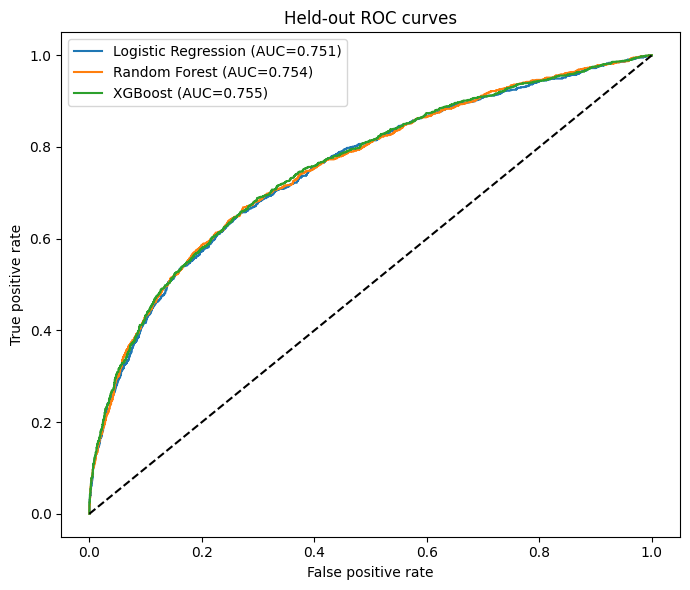

In [19]:
# CELL 16 — ROC curves
plt.figure(figsize=(7,6))
for name,p in probs.items():
    fpr,tpr,_=roc_curve(y_test,p); plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,p):.3f})')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('Held-out ROC curves'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_roc.png',dpi=300); plt.show()

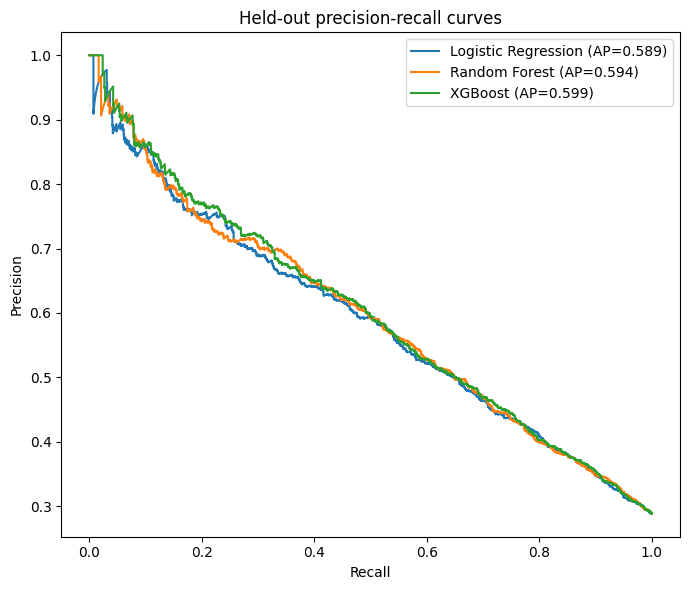

In [20]:
# CELL 17 — Precision-recall curves
plt.figure(figsize=(7,6))
for name,p in probs.items():
    pr,re,_=precision_recall_curve(y_test,p); plt.plot(re,pr,label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Held-out precision-recall curves'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_pr.png',dpi=300); plt.show()

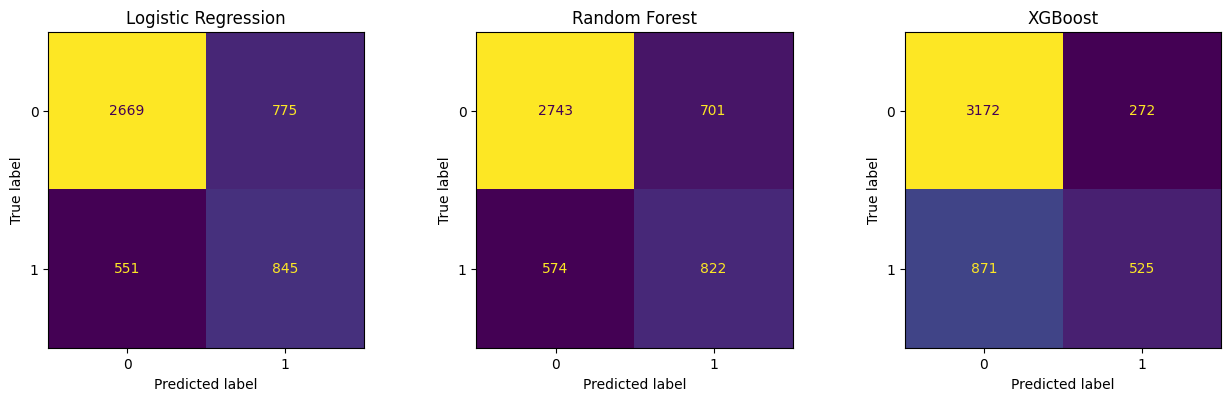

In [21]:
# CELL 18 — Confusion matrices
fig,axs=plt.subplots(1,3,figsize=(13,4))
for ax,(name,p) in zip(axs,probs.items()):
    ConfusionMatrixDisplay.from_predictions(y_test,(p>=.5).astype(int),ax=ax,colorbar=False); ax.set_title(name)
plt.tight_layout(); plt.savefig('/content/figure_confusion.png',dpi=300); plt.show()

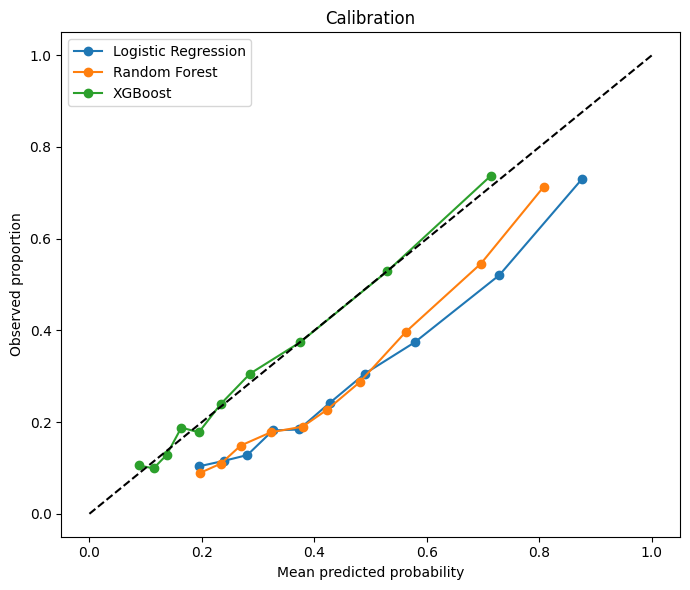

In [22]:
# CELL 19 — Calibration
plt.figure(figsize=(7,6))
for name,p in probs.items():
    frac,mean=calibration_curve(y_test,p,n_bins=10,strategy='quantile'); plt.plot(mean,frac,marker='o',label=name)
plt.plot([0,1],[0,1],'k--'); plt.xlabel('Mean predicted probability'); plt.ylabel('Observed proportion'); plt.title('Calibration'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_calibration.png',dpi=300); plt.show()

,Feature,Importance,SD
17,PHQCAT_A,0.085693,0.006426
5,PHSTAT_A,0.039425,0.003076
6,LSATIS4_A,0.019542,0.003706
18,GADCAT_A,0.005637,0.001265
0,AGEP_A,0.005290,0.001144
15,ANXEV_A,0.000518,0.000248
3,RACEALLP_A,0.000251,0.000180
1,SEX_A,0.000191,0.000094
12,SMKCIGST_A,0.000182,0.000492
4,EDUCP_A,0.000145,0.000402


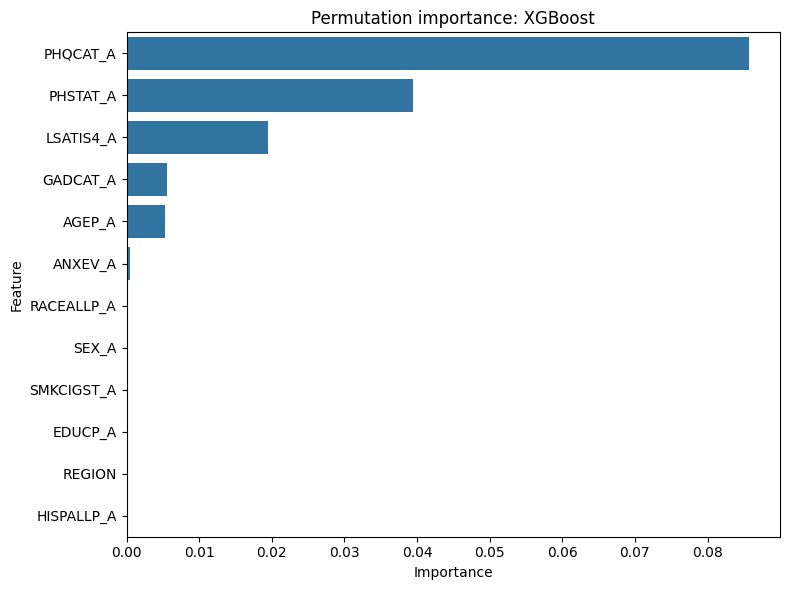

In [23]:
# CELL 20 — Model-agnostic permutation importance on held-out data
winner=test_results.iloc[0]['Model']; final_model=best[winner]
pi=permutation_importance(final_model,X_test,y_test,n_repeats=10,scoring='roc_auc',random_state=RANDOM_STATE,n_jobs=-1)
imp=pd.DataFrame({'Feature':features,'Importance':pi.importances_mean,'SD':pi.importances_std}).sort_values('Importance',ascending=False)
display(imp.head(15)); imp.to_csv('/content/table6_permutation_importance.csv',index=False)
plt.figure(figsize=(8,6)); sns.barplot(data=imp.head(12),x='Importance',y='Feature'); plt.title(f'Permutation importance: {winner}'); plt.tight_layout(); plt.savefig('/content/figure_importance.png',dpi=300); plt.show()

In [24]:
# CELL 21 — Subgroup performance and fairness diagnostics
# These are descriptive model-audit metrics, not proof that a model is fair.
def subgroup_metrics(group_col,min_n=100):
    if group_col not in X_test: return pd.DataFrame()
    out=[]
    temp=pd.DataFrame({'group':X_test[group_col].astype(str),'y':y_test.values,'p':probs[winner]},index=X_test.index)
    for g,d in temp.groupby('group'):
        if len(d)<min_n or d.y.nunique()<2: continue
        pred=(d.p>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(d.y,pred).ravel()
        out.append({'Variable':group_col,'Group':g,'N':len(d),'Prevalence':d.y.mean(),'ROC-AUC':roc_auc_score(d.y,d.p),
                    'Sensitivity':tp/(tp+fn) if tp+fn else np.nan,'Specificity':tn/(tn+fp) if tn+fp else np.nan,
                    'FPR':fp/(fp+tn) if fp+tn else np.nan,'FNR':fn/(fn+tp) if fn+tp else np.nan})
    return pd.DataFrame(out)
subs=pd.concat([subgroup_metrics(c) for c in ['SEX_A','HISPALLP_A','RACEALLP_A'] if c in X_test],ignore_index=True)
display(subs); subs.to_csv('/content/table5_subgroup_performance.csv',index=False)

,Variable,Group,N,Prevalence,ROC-AUC,Sensitivity,Specificity,FPR,FNR
0,SEX_A,1.0,2268,0.276455,0.746860,0.330144,0.938452,0.061548,0.669856
1,SEX_A,2.0,2567,0.299182,0.761808,0.414062,0.904947,0.095053,0.585938
2,HISPALLP_A,1.0,702,0.287749,0.749861,0.311881,0.928000,0.072000,0.688119
3,HISPALLP_A,2.0,3188,0.280427,0.753219,0.388143,0.917611,0.082389,0.611857
4,HISPALLP_A,3.0,545,0.359633,0.751791,0.408163,0.916905,0.083095,0.591837
5,HISPALLP_A,4.0,279,0.222222,0.752118,0.241935,0.958525,0.041475,0.758065
6,RACEALLP_A,1,3596,0.279477,0.753094,0.377114,0.919336,0.080664,0.622886
7,RACEALLP_A,2,569,0.363796,0.752896,0.400966,0.917127,0.082873,0.599034
8,RACEALLP_A,3,280,0.225000,0.754663,0.238095,0.958525,0.041475,0.761905
9,RACEALLP_A,8,245,0.289796,0.717824,0.338028,0.925287,0.074713,0.661972


In [25]:
# CELL 22 — Age-band audit
if 'AGEP_A' in X_test:
    age=pd.to_numeric(X_test['AGEP_A'],errors='coerce')
    age_band=pd.cut(age,[17,34,49,64,200],labels=['18-34','35-49','50-64','65+'])
    audit=pd.DataFrame({'age_band':age_band,'y':y_test.values,'p':probs[winner]})
    rows=[]
    for g,d in audit.groupby('age_band',observed=True):
        d=d.dropna()
        if len(d)>=100 and d.y.nunique()==2:
            pred=(d.p>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(d.y,pred).ravel()
            rows.append([g,len(d),roc_auc_score(d.y,d.p),tp/(tp+fn),tn/(tn+fp)])
    age_results=pd.DataFrame(rows,columns=['Age group','N','ROC-AUC','Sensitivity','Specificity'])
    display(age_results); age_results.to_csv('/content/table5b_age_performance.csv',index=False)

,Age group,N,ROC-AUC,Sensitivity,Specificity
0,18-34,960,0.763097,0.401515,0.915230
1,35-49,1084,0.752581,0.386885,0.906290
2,50-64,1117,0.745073,0.389333,0.927224
3,65+,1679,0.757812,0.342920,0.929910


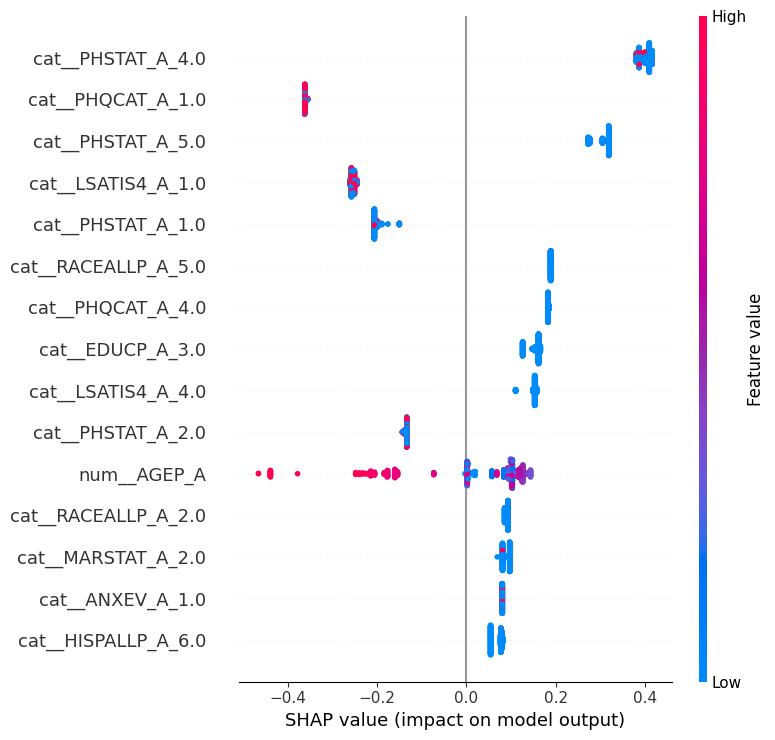

In [26]:
# CELL 23 — Optional SHAP for tree winner
if winner in ['Random Forest','XGBoost']:
    import shap
    transformed=final_model.named_steps['pre'].transform(X_test.iloc[:500])
    names=final_model.named_steps['pre'].get_feature_names_out()
    if hasattr(transformed,'toarray'): transformed=transformed.toarray()
    explainer=shap.TreeExplainer(final_model.named_steps['model'])
    sv=explainer.shap_values(transformed)
    if isinstance(sv,list): sv=sv[-1]
    if getattr(sv,'ndim',0)==3: sv=sv[:,:,1]
    shap.summary_plot(sv,transformed,feature_names=names,max_display=15,show=False)
    plt.tight_layout(); plt.savefig('/content/figure_shap.png',dpi=300,bbox_inches='tight'); plt.show()
else:
    print('Winner is Logistic Regression; permutation importance above provides model-agnostic interpretability.')

In [27]:
# CELL 24 — Survey-weighted poor self-rated sleep-health prevalence

if "WTFA_A" in df.columns:

    # Use the same observations included in the analytic outcome
    valid_idx = model_df.index

    weights = pd.to_numeric(
        df.loc[valid_idx, "WTFA_A"],
        errors="coerce"
    )

    outcomes = model_df.loc[valid_idx, "target"]

    valid = (
        weights.notna()
        & outcomes.notna()
        & (weights > 0)
    )

    weighted_prevalence = np.average(
        outcomes.loc[valid],
        weights=weights.loc[valid]
    )

    unweighted_prevalence = outcomes.loc[valid].mean()

    print(
        "NHIS final-weighted prevalence of poor "
        f"self-rated sleep health: {weighted_prevalence:.1%}"
    )

    print(
        "Unweighted analytic prevalence of poor "
        f"self-rated sleep health: {unweighted_prevalence:.1%}"
    )

    print(
        f"Observations included: {valid.sum():,}"
    )

else:
    print(
        "WTFA_A was not found. "
        "Survey-weighted prevalence was not calculated."
    )

NHIS final-weighted prevalence of poor self-rated sleep health: 28.3%
Unweighted analytic prevalence of poor self-rated sleep health: 28.8%
Observations included: 24,200


In [29]:
# CELL 25 — Reproducibility metadata and output bundle

import platform
import sklearn
import xgboost
import glob
import json
import os
import zipfile

# Identify selected model if test evaluation has been completed
selected_model = (
    winner
    if "winner" in globals()
    else None
)

meta = {
    "study": (
        "Python-Based Predictive Analytics for "
        "Poor Self-Rated Sleep Health"
    ),
    "data_source": (
        "CDC/NCHS 2025 National Health Interview Survey "
        "Sample Adult Public-Use File"
    ),
    "dataset_url": URL,
    "random_state": RANDOM_STATE,
    "n_raw": int(len(df)),
    "n_analytic": int(len(model_df)),
    "outcome_variable": "WPHSLEEP_A",
    "outcome_name": "poor_sleep_health",
    "outcome_definition": {
        "0": "Excellent, Very Good, or Good",
        "1": "Fair or Poor",
        "missing": "Refused, Not Ascertained, or Don't Know"
    },
    "predictors": features,
    "selected_model_by_test_roc_auc": selected_model,
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__
}

# Save metadata
metadata_path = "/content/reproducibility.json"

with open(metadata_path, "w") as f:
    json.dump(
        meta,
        f,
        indent=2
    )

# Collect generated tables and figures
output_files = (
    glob.glob("/content/table*.csv")
    + glob.glob("/content/figure*.png")
    + [metadata_path]
)

# Retain only files that exist
output_files = [
    f for f in output_files
    if os.path.exists(f)
]

# Create reproducibility bundle
bundle_path = "/content/NHIS2025_sleep_health_results.zip"

with zipfile.ZipFile(
    bundle_path,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for f in output_files:
        z.write(
            f,
            arcname=os.path.basename(f)
        )

print("Reproducibility metadata:")
print(json.dumps(meta, indent=2))

print(
    f"\nSaved {len(output_files)} research outputs to:"
)
print(bundle_path)

Reproducibility metadata:
{
  "study": "Python-Based Predictive Analytics for Poor Self-Rated Sleep Health",
  "data_source": "CDC/NCHS 2025 National Health Interview Survey Sample Adult Public-Use File",
  "dataset_url": "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/NHIS/2025/adult25csv.zip",
  "random_state": 42,
  "n_raw": 24215,
  "n_analytic": 24200,
  "outcome_variable": "WPHSLEEP_A",
  "outcome_name": "poor_sleep_health",
  "outcome_definition": {
    "0": "Excellent, Very Good, or Good",
    "1": "Fair or Poor",
    "missing": "Refused, Not Ascertained, or Don't Know"
  },
  "predictors": [
    "AGEP_A",
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "PHSTAT_A",
    "LSATIS4_A",
    "REGION",
    "URBRRL23",
    "MARSTAT_A",
    "EMPWRKLSW1_A",
    "BMICAT_A",
    "SMKCIGST_A",
    "CHLEV_A",
    "DIBEV_A",
    "ANXEV_A",
    "DEPEV_A",
    "PHQCAT_A",
    "GADCAT_A"
  ],
  "selected_model_by_test_roc_auc": "XGBoost",
  "python_version": "3.13.16